# The Multivariate Gaussian: density, sampling, conditioning

The multivariate normal (MVN) distribution is the workhorse of Gaussian processes, Kalman filtering, and most of variational inference. This notebook is the pedagogical entry point for the GP tutorial sequence: by the end you should have a working mental model of $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ and a feel for the three operations every later notebook will lean on — *evaluating the density*, *drawing samples*, and *conditioning on a sub-vector*.

**What you'll learn**

1. The MVN density, its level sets, and why $\boldsymbol{\Sigma}$ must be positive definite.
2. Three equivalent ways to sample from an MVN, all driven by the same standard-normal noise.
3. How marginalization and conditioning act on $(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ — the Schur complement.
4. Why naive `inv(Sigma)` is a bad idea, and what `gaussx` gives you instead.

:::{important}
This is a *foundations* notebook. Computations are deliberately tiny so the math stays in focus. The same operations scale to thousands of dimensions via the structured operators introduced in [Part 1 — Structured Linear Operators](../01_operators/) and the matrix-free solvers in [Part 1.D](../01_operators/) — but here we use dense matrices and lean on $2$- and $3$-dimensional pictures wherever possible.
:::

:::{note}
Linear-algebra ops in this notebook use [`einx`](https://github.com/fferflo/einx) (`einx.dot("...", A, B)`) instead of `@` / `jnp.einsum`. Each contraction names every index — `einx.dot("i j, j -> i", A, x)` reads as "matrix-vector product over the shared `j`". It's verbose for trivial ops but pays off the moment broadcasts, transposes, or batches show up. We'll lean on the same convention throughout the GP curriculum.
:::

## 1. The density

A random vector $\mathbf{x}\in\mathbb{R}^d$ is **multivariate normal** with mean $\boldsymbol{\mu}\in\mathbb{R}^d$ and covariance $\boldsymbol{\Sigma}\in\mathbb{R}^{d\times d}$ when its density is

$$ p(\mathbf{x}) = (2\pi)^{-d/2}\,|\boldsymbol{\Sigma}|^{-1/2} \exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right). $$ (eq:mvn-density)

Three things are doing real work in equation [](#eq:mvn-density):

- $(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})$ is a **squared Mahalanobis distance** — the Euclidean norm rescaled by the geometry of $\boldsymbol{\Sigma}$.
- $|\boldsymbol{\Sigma}|^{-1/2}$ is a normalization that makes the density integrate to 1; it grows when $\boldsymbol{\Sigma}$ shrinks.
- $\boldsymbol{\Sigma}$ must be **symmetric positive-definite (SPD)** so that the quadratic form is non-negative, the inverse exists, and the density is well defined.

The *log* density is the version we actually compute, because $\log|\boldsymbol{\Sigma}|$ is much more stable than $|\boldsymbol{\Sigma}|$:

$$ \log p(\mathbf{x}) = -\tfrac{d}{2}\log(2\pi) - \tfrac{1}{2}\log|\boldsymbol{\Sigma}| - \tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu}). $$ (eq:mvn-logprob)

:::{note}
Equation [](#eq:mvn-logprob) is exactly what `gaussx.gaussian_log_prob` evaluates — and it does so by Cholesky-factoring $\boldsymbol{\Sigma}$ once and reusing the factor for both the quadratic form and the log-determinant. You'll see this pattern repeatedly.
:::

In [1]:
from __future__ import annotations

import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    MultivariateNormal,
    add_jitter,
    cholesky,
    conditional,
    gaussian_log_prob,
    schur_complement,
    solve,
    sqrt,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams["figure.dpi"] = 110


In [2]:
mu = jnp.array([0.5, -0.25])
Sigma = jnp.array([[1.0, 0.7],
                   [0.7, 1.5]])
Sigma_op = lx.MatrixLinearOperator(Sigma, lx.positive_semidefinite_tag)

p = MultivariateNormal(mu, Sigma_op)
print("event_shape :", p.event_shape)
print("mean        :", np.asarray(p.mean))
print("variance    :", np.asarray(p.variance))
print("log p(mu)   :", float(p.log_prob(mu)))


event_shape : (2,)
mean        : [ 0.5  -0.25]
variance    : [1.  1.5]


log p(mu)   : -1.8428522318359293


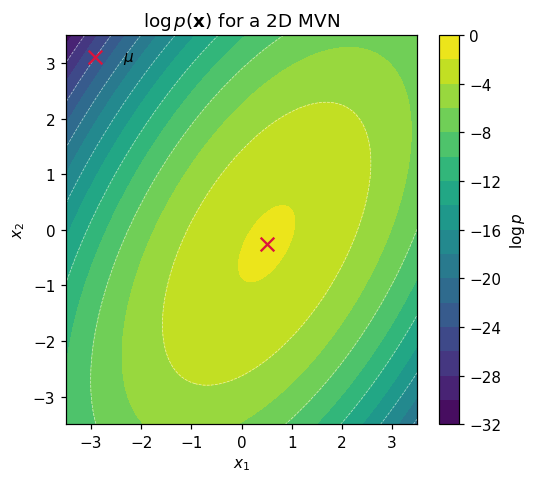

In [3]:
xs = jnp.linspace(-3.5, 3.5, 200)
ys = jnp.linspace(-3.5, 3.5, 200)
XX, YY = jnp.meshgrid(xs, ys)
grid = jnp.stack([XX.ravel(), YY.ravel()], axis=-1)

logp = jax.vmap(p.log_prob)(grid).reshape(XX.shape)

fig, ax = plt.subplots(figsize=(5.0, 4.5))
cs = ax.contourf(np.asarray(XX), np.asarray(YY), np.asarray(logp), levels=18, cmap="viridis")
ax.contour(np.asarray(XX), np.asarray(YY), np.asarray(logp), levels=8, colors="white", linewidths=0.5, alpha=0.6)
ax.scatter(*np.asarray(mu), color="crimson", marker="x", s=80, label=r"$\mu$")
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.set_title(r"$\log p(\mathbf{x})$ for a 2D MVN")
ax.legend(loc="upper left", frameon=False)
plt.colorbar(cs, ax=ax, label=r"$\log p$")
plt.tight_layout(); plt.show()


## 2. The geometry of the covariance

The level sets of equation [](#eq:mvn-density) are *ellipsoids* defined by

$$ \{\mathbf{x} : (\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu}) = c^2 \}, $$ (eq:mahalanobis-ellipse)

and the eigendecomposition

$$ \boldsymbol{\Sigma} = \mathbf{Q}\,\boldsymbol{\Lambda}\,\mathbf{Q}^\top, \qquad \boldsymbol{\Lambda} = \mathrm{diag}(\lambda_1, \dots, \lambda_d), \quad \lambda_i > 0, $$ (eq:cov-eig)

reads off those ellipsoids directly: the columns of $\mathbf{Q}$ are the *principal axes*, and $\sqrt{\lambda_i}$ is the radius along axis $i$. So $\boldsymbol{\Sigma}$ is geometry — orientation plus scale — and SPD-ness is exactly the requirement that all principal radii be real and positive.

The figure below draws 1-, 2-, and 3-$\sigma$ Mahalanobis ellipses on top of samples from $p$ and overlays the principal axes. The two eigenvalues differ by ${\sim}3.5\times$, which is why the cloud is visibly elongated.

eigenvalues : [0.50669656 1.99330344]
eigenvectors (columns):
 [[-0.81741556  0.57604844]
 [ 0.57604844  0.81741556]]


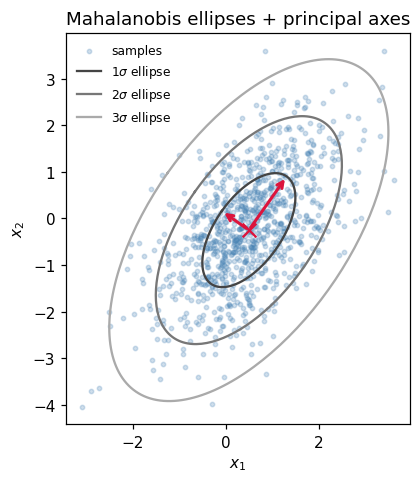

In [4]:
eigvals, eigvecs = jnp.linalg.eigh(Sigma)
print("eigenvalues :", np.asarray(eigvals))
print("eigenvectors (columns):\n", np.asarray(eigvecs))

samples = p.sample(jax.random.PRNGKey(1), (1000,))

theta = jnp.linspace(0, 2 * jnp.pi, 200)
unit_circle = jnp.stack([jnp.cos(theta), jnp.sin(theta)], axis=0)  # (axis=2, theta=200)

# Stretch the unit circle by the principal radii sqrt(lambda), then rotate by Q:
#   ellipse = Q @ diag(sqrt(lambda)) @ unit_circle
# Done in two einx.dot steps to keep every index named.
sqrt_lambda = jnp.sqrt(eigvals)
stretched = einx.multiply("j, j t -> j t", sqrt_lambda, unit_circle)
ellipse_template = einx.dot("i j, j t -> i t", eigvecs, stretched)

fig, ax = plt.subplots(figsize=(5.0, 4.5))
ax.scatter(*np.asarray(samples).T, s=8, alpha=0.25, color="steelblue", label="samples")
for c, color in zip([1.0, 2.0, 3.0], ["#444", "#777", "#aaa"]):
    ellipse = c * ellipse_template
    ax.plot(np.asarray(ellipse[0]) + float(mu[0]),
            np.asarray(ellipse[1]) + float(mu[1]),
            color=color, lw=1.5, label=fr"${int(c)}\sigma$ ellipse")
for i in range(2):
    axis = np.asarray(eigvecs[:, i]) * np.sqrt(float(eigvals[i]))
    ax.annotate("", xy=np.asarray(mu) + axis, xytext=np.asarray(mu),
                arrowprops=dict(arrowstyle="->", color="crimson", lw=2.0))
ax.scatter(*np.asarray(mu), color="crimson", marker="x", s=80)
ax.set_aspect("equal")
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.set_title("Mahalanobis ellipses + principal axes")
ax.legend(loc="upper left", frameon=False, fontsize=8)
plt.tight_layout(); plt.show()


## 3. Three ways to sample

Sampling an MVN reduces to **whitening in reverse**: take standard normal noise $\boldsymbol{\varepsilon}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ and multiply by *any* matrix square root of $\boldsymbol{\Sigma}$. Concretely, if $\mathbf{R}\mathbf{R}^\top = \boldsymbol{\Sigma}$ then

$$ \mathbf{x} = \boldsymbol{\mu} + \mathbf{R}\,\boldsymbol{\varepsilon} \;\Longrightarrow\; \mathbb{E}[\mathbf{x}] = \boldsymbol{\mu}, \quad \mathrm{Cov}[\mathbf{x}] = \mathbf{R}\,\mathbb{I}\,\mathbf{R}^\top = \boldsymbol{\Sigma}. $$ (eq:mvn-sample)

Three common choices for $\mathbf{R}$:

1. **Cholesky factor** — $\mathbf{R} = \mathbf{L}$, the unique lower-triangular $\mathbf{L}$ with positive diagonal such that $\mathbf{L}\mathbf{L}^\top = \boldsymbol{\Sigma}$. Cheapest, most stable, the default in `gaussx`.
2. **Eigendecomposition** — $\mathbf{R} = \mathbf{Q}\,\boldsymbol{\Lambda}^{1/2}$ from equation [](#eq:cov-eig). Useful when you need the principal axes anyway, or when $\boldsymbol{\Sigma}$ has known structure.
3. **Symmetric square root** — $\mathbf{R} = \boldsymbol{\Sigma}^{1/2}$, the unique SPD matrix with $\mathbf{R}\mathbf{R} = \boldsymbol{\Sigma}$. Has the nice property of being symmetric, occasionally needed for *re-symmetrising* updates (e.g. ensemble Kalman square-root filters).

All three give the same distribution. Below we drive each route with the *same* noise and check that the empirical covariance matches $\boldsymbol{\Sigma}$.

In [5]:
d = 2
N = 10_000
eps = jax.random.normal(jax.random.PRNGKey(2), (N, d))

def transform(eps, R):
    """x_n = mu + R @ eps_n, batched over n.  einx names every index."""
    return mu + einx.dot("n j, i j -> n i", eps, R)

# 1. Cholesky:  L Lᵀ = Sigma
L = cholesky(Sigma_op).as_matrix()
samples_chol = transform(eps, L)

# 2. Eigendecomposition: R = Q diag(sqrt(lambda)) — scale columns of Q by sqrt(lambda).
R_eig = einx.multiply("i j, j -> i j", eigvecs, jnp.sqrt(eigvals))
samples_eig = transform(eps, R_eig)

# 3. Symmetric square root via gaussx.sqrt:  R R = Sigma, R = Rᵀ
R_sym = sqrt(Sigma_op).as_matrix()
samples_sym = transform(eps, R_sym)

def empirical_cov(s):
    s_centred = s - s.mean(axis=0, keepdims=True)
    # (1 / (N-1)) * sum_n s_n s_nᵀ
    return einx.dot("n i, n j -> i j", s_centred, s_centred) / (s.shape[0] - 1)

for label, s in [("Cholesky", samples_chol),
                 ("Eigendecomp", samples_eig),
                 ("Symmetric sqrt", samples_sym)]:
    err = float(jnp.linalg.norm(empirical_cov(s) - Sigma))
    print(f"  {label:16s} -> ||emp_cov - Sigma||_F = {err:.4f}")

# Verify the symmetric sqrt really is symmetric (and squares to Sigma)
R_sym_squared = einx.dot("i j, j k -> i k", R_sym, R_sym)
print("\nsymmetric?           ", bool(jnp.allclose(R_sym, R_sym.T)))
print("R_sym @ R_sym ≈ Sigma:", bool(jnp.allclose(R_sym_squared, Sigma, atol=1e-8)))


  Cholesky         -> ||emp_cov - Sigma||_F = 0.0179
  Eigendecomp      -> ||emp_cov - Sigma||_F = 0.0409
  Symmetric sqrt   -> ||emp_cov - Sigma||_F = 0.0235

symmetric?            True
R_sym @ R_sym ≈ Sigma: True


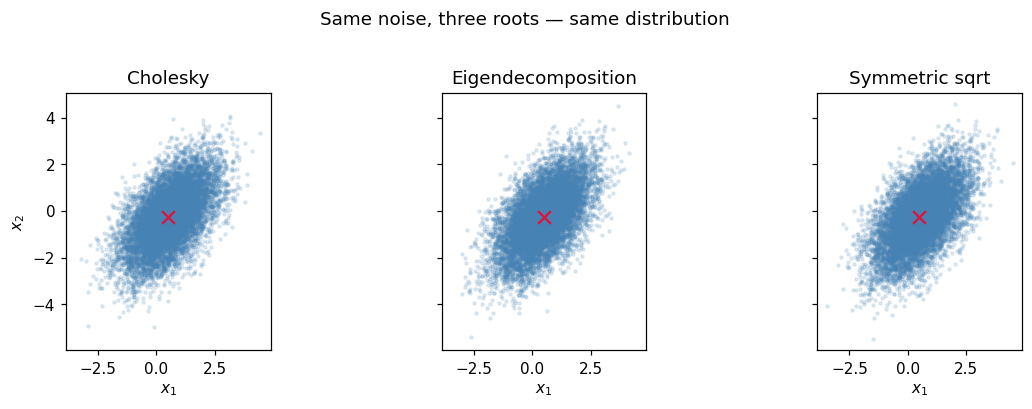

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True, sharey=True)
for ax, s, title in zip(axes,
                        [samples_chol, samples_eig, samples_sym],
                        ["Cholesky", "Eigendecomposition", "Symmetric sqrt"]):
    ax.scatter(*np.asarray(s).T, s=4, alpha=0.15, color="steelblue")
    ax.scatter(*np.asarray(mu), marker="x", color="crimson", s=70)
    ax.set_aspect("equal"); ax.set_title(title)
    ax.set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$")
fig.suptitle("Same noise, three roots — same distribution", y=1.02)
plt.tight_layout(); plt.show()


:::{tip}
Whichever root you use is a *computational* choice; the distribution is the same. Cholesky wins on cost ($O(d^3/3)$ vs ${\sim}9d^3$ for eigendecomp), but the eigen route gives you the principal axes for free, and the symmetric root is occasionally required for variance-preserving updates (see the ensemble Kalman tutorial in [Part 11](../11_ensembles/)).
:::

## 4. Marginalization

Partition $\mathbf{x} = (\mathbf{x}_a, \mathbf{x}_b)$ with $\mathbf{x}_a\in\mathbb{R}^{d_a}$ and $\mathbf{x}_b\in\mathbb{R}^{d_b}$, and write the joint as

$$ \boldsymbol{\mu} = \begin{bmatrix}\boldsymbol{\mu}_a\\\boldsymbol{\mu}_b\end{bmatrix}, \qquad \boldsymbol{\Sigma} = \begin{bmatrix} \boldsymbol{\Sigma}_{aa} & \boldsymbol{\Sigma}_{ab}\\ \boldsymbol{\Sigma}_{ba} & \boldsymbol{\Sigma}_{bb} \end{bmatrix}. $$ (eq:mvn-partition)

The marginal of $\mathbf{x}_a$ is obtained simply by *dropping the $b$ rows and columns*:

$$ \mathbf{x}_a \sim \mathcal{N}(\boldsymbol{\mu}_a,\, \boldsymbol{\Sigma}_{aa}). $$ (eq:mvn-marginal)

This is striking: marginalization is "look up the right block". Compare the cost of integrating out $\mathbf{x}_b$ from the joint density by hand — which involves completing the square — to the act of indexing into a matrix. The integral is *automatic* for Gaussians.

marginal mean    : [0.5]
marginal variance: 1.0


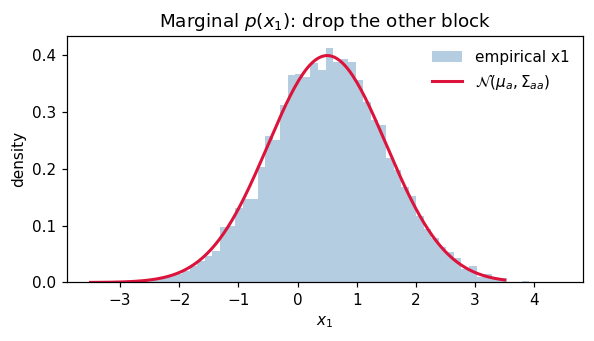

In [7]:
mu_a = mu[:1]
Sigma_aa = Sigma[:1, :1]
print("marginal mean    :", np.asarray(mu_a))
print("marginal variance:", float(Sigma_aa[0, 0]))

# Sanity: empirical marginal of x_1 from joint samples
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.hist(np.asarray(samples_chol[:, 0]), bins=60, density=True,
        color="steelblue", alpha=0.4, label="empirical x1")
xs1 = jnp.linspace(-3.5, 3.5, 200)
pdf = jnp.exp(-0.5 * ((xs1 - mu_a) / jnp.sqrt(Sigma_aa))**2) / jnp.sqrt(2 * jnp.pi * Sigma_aa)
ax.plot(np.asarray(xs1), np.asarray(pdf).ravel(), color="crimson", lw=2, label=r"$\mathcal{N}(\mu_a, \Sigma_{aa})$")
ax.set_xlabel(r"$x_1$"); ax.set_ylabel("density")
ax.set_title("Marginal $p(x_1)$: drop the other block")
ax.legend(frameon=False); plt.tight_layout(); plt.show()


## 5. Conditioning — the Schur complement

The conditional $p(\mathbf{x}_a \mid \mathbf{x}_b = \mathbf{b})$ is also Gaussian, with mean and covariance

$$ \boldsymbol{\mu}_{a\mid b} = \boldsymbol{\mu}_a + \boldsymbol{\Sigma}_{ab}\,\boldsymbol{\Sigma}_{bb}^{-1}\,(\mathbf{b} - \boldsymbol{\mu}_b), $$ (eq:cond-mean)

$$ \boldsymbol{\Sigma}_{a\mid b} = \boldsymbol{\Sigma}_{aa} - \boldsymbol{\Sigma}_{ab}\,\boldsymbol{\Sigma}_{bb}^{-1}\,\boldsymbol{\Sigma}_{ba}. $$ (eq:cond-cov)

The matrix $\boldsymbol{\Sigma}_{aa} - \boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}\boldsymbol{\Sigma}_{ba}$ is called the **Schur complement** of $\boldsymbol{\Sigma}_{bb}$ in $\boldsymbol{\Sigma}$. Two useful intuitions:

- **Mean shift.** Equation [](#eq:cond-mean) is a *linear regression*: we subtract the prior on $\mathbf{x}_b$, regress the residual onto $\mathbf{x}_a$ via the cross-covariance, and add it to the prior mean of $\mathbf{x}_a$. The regression coefficient is $\boldsymbol{\Sigma}_{ab}\boldsymbol{\Sigma}_{bb}^{-1}$.
- **Variance reduction.** Equation [](#eq:cond-cov) shows $\boldsymbol{\Sigma}_{a\mid b} \preceq \boldsymbol{\Sigma}_{aa}$ — observing $\mathbf{x}_b$ never *increases* uncertainty in $\mathbf{x}_a$. The reduction is exactly the variance "explained" by $\mathbf{x}_b$.

`gaussx` provides `conditional(loc, cov, obs_idx, obs_values)` and `schur_complement(K_XX, K_XZ, K_ZZ)` — equation [](#eq:cond-cov). We use the high-level `conditional` here.

In [8]:
def cond_density(b_value: float):
    """p(x_1 | x_2 = b_value) — returns (mean, std)."""
    new_loc, new_cov_op = conditional(
        loc=mu,
        cov=Sigma_op,
        obs_idx=jnp.array([1]),
        obs_values=jnp.array([b_value]),
    )
    new_cov = new_cov_op.as_matrix()
    return float(new_loc[0]), float(jnp.sqrt(new_cov[0, 0]))

for b in [-2.0, -0.5, 0.0, 1.5]:
    m, s = cond_density(b)
    print(f"  x_2 = {b:+.2f}  ->  x_1 | x_2 ~ N({m:+.3f}, {s**2:.3f})")


  x_2 = -2.00  ->  x_1 | x_2 ~ N(-0.317, 0.673)
  x_2 = -0.50  ->  x_1 | x_2 ~ N(+0.383, 0.673)
  x_2 = +0.00  ->  x_1 | x_2 ~ N(+0.617, 0.673)
  x_2 = +1.50  ->  x_1 | x_2 ~ N(+1.317, 0.673)


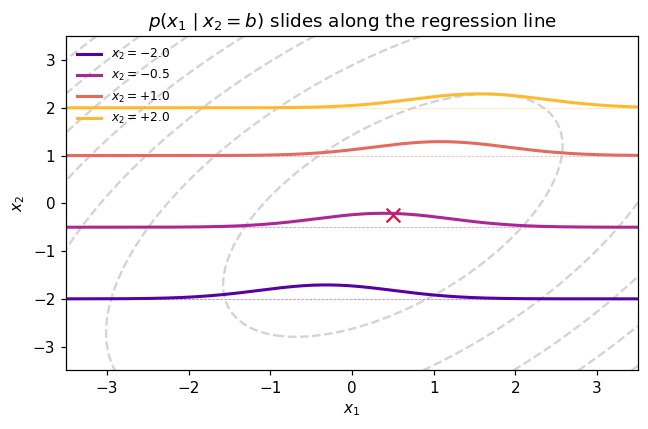

In [9]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.contour(np.asarray(XX), np.asarray(YY), np.asarray(logp), levels=8, colors="lightgray")
ax.scatter(*np.asarray(mu), marker="x", color="crimson", s=80)

xs1 = jnp.linspace(-3.5, 3.5, 300)
b_values = [-2.0, -0.5, 1.0, 2.0]
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(b_values)))

for b, col in zip(b_values, colors):
    m, s = cond_density(b)
    pdf = jnp.exp(-0.5 * ((xs1 - m) / s) ** 2) / (s * jnp.sqrt(2 * jnp.pi))
    # Plot conditional density along x_2 = b, scaled for visibility
    ax.plot(np.asarray(xs1), b + 0.6 * np.asarray(pdf), color=col, lw=2,
            label=fr"$x_2 = {b:+.1f}$")
    ax.axhline(b, color=col, lw=0.5, ls="--", alpha=0.5)

ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.set_title(r"$p(x_1 \mid x_2 = b)$ slides along the regression line")
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()


:::{seealso}
Conditioning *is* GP regression. The posterior over latent function values at test points $\mathbf{x}_*$, given training data $\mathbf{y}$, is exactly equation [](#eq:cond-mean)–[](#eq:cond-cov) applied to a joint Gaussian over $(\mathbf{f}_*, \mathbf{y})$. We unpack that in [3.2 — Exact GP regression](../03_exact_gp/).
:::

## 6. Numerical mechanics: don't `inv(Sigma)`

Equations [](#eq:mvn-density), [](#eq:mvn-logprob), [](#eq:cond-mean), and [](#eq:cond-cov) all contain $\boldsymbol{\Sigma}^{-1}$. **You never form that inverse.** Two reasons:

- **Cost.** Forming $\boldsymbol{\Sigma}^{-1}$ explicitly is $O(d^3)$ and then *every* subsequent multiply is $O(d^2)$. Cholesky-factoring once and doing two triangular solves is also $O(d^3)$ — but with a smaller constant — and reuses the factor for the log-determinant.
- **Stability.** Triangular solves preserve more digits than explicit inversion. The condition number of $\mathbf{L}$ is $\sqrt{\kappa(\boldsymbol{\Sigma})}$, which is much friendlier than $\kappa(\boldsymbol{\Sigma})$ itself.

The recipe `gaussx` uses internally is

$$ \boldsymbol{\Sigma}=\mathbf{L}\mathbf{L}^\top,\quad \mathbf{z} = \mathbf{L}^{-1}(\mathbf{x}-\boldsymbol{\mu}),\quad \log p = -\tfrac{d}{2}\log(2\pi) - \sum_i \log L_{ii} - \tfrac{1}{2}\|\mathbf{z}\|^2, $$ (eq:logprob-cholesky)

and when $\boldsymbol{\Sigma}$ is borderline-PD (e.g. a kernel matrix on nearly-coincident inputs), we add a tiny multiple of the identity — **jitter** — until the Cholesky succeeds.

In [10]:
# Build a deliberately ill-conditioned covariance: two nearly-collinear cols.
d_test = 5
A = jnp.array([[1.0, 0.999, 0.5, 0.2, 0.1]])  # row vector, shape (1, d_test)
# Sigma = Aᵀ A + 1e-12 I — written with named indices via einx.
Sigma_bad = einx.dot("k i, k j -> i j", A, A) + 1e-12 * jnp.eye(d_test)
kappa = float(jnp.linalg.cond(Sigma_bad))
print(f"cond(Sigma) ~ {kappa:.2e}")

x_test = jnp.zeros(d_test)
mu_test = jnp.zeros(d_test)
delta = x_test - mu_test

# Naive: explicit inverse + log|det|, quadratic form via einx.
Sinv = jnp.linalg.inv(Sigma_bad)
sign, logabsdet = jnp.linalg.slogdet(Sigma_bad)
quad_naive = einx.dot("i, i j, j ->", delta, Sinv, delta)
logp_naive = -0.5 * d_test * jnp.log(2 * jnp.pi) - 0.5 * logabsdet - 0.5 * quad_naive

# Robust: jitter + Cholesky via gaussx
Sigma_op_bad = lx.MatrixLinearOperator(Sigma_bad, lx.positive_semidefinite_tag)
Sigma_op_jit = add_jitter(Sigma_op_bad, jitter=1e-8)
logp_gaussx = float(gaussian_log_prob(mu_test, Sigma_op_jit, x_test))

print(f"naive log p  : {float(logp_naive):+.6f}  (sign|det| = {int(sign):+d})")
print(f"gaussx log p : {logp_gaussx:+.6f}")


cond(Sigma) ~ 2.30e+12


naive log p  : +50.251326  (sign|det| = +1)
gaussx log p : +31.830449


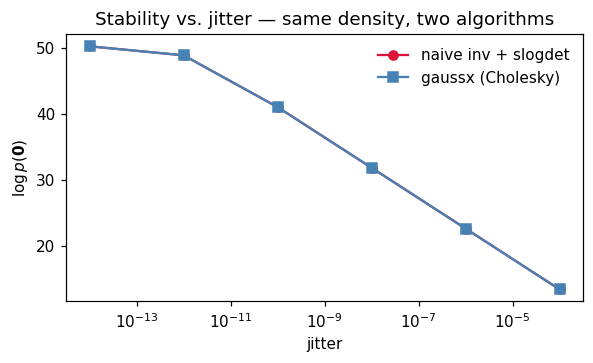

In [11]:
# Sweep jitter and watch the naive route fall apart while gaussx stays sane.
jitters = jnp.array([1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-4])
naive, robust = [], []
for j in jitters:
    S = Sigma_bad + j * jnp.eye(d_test)
    try:
        Sinv = jnp.linalg.inv(S)
        _, lad = jnp.linalg.slogdet(S)
        lp = -0.5 * d_test * jnp.log(2 * jnp.pi) - 0.5 * lad
        naive.append(float(lp))
    except Exception:
        naive.append(np.nan)
    op = lx.MatrixLinearOperator(S, lx.positive_semidefinite_tag)
    try:
        robust.append(float(gaussian_log_prob(mu_test, op, x_test)))
    except Exception:
        robust.append(np.nan)

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.plot(np.asarray(jitters), naive, "o-", label="naive inv + slogdet", color="crimson")
ax.plot(np.asarray(jitters), robust, "s-", label="gaussx (Cholesky)", color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("jitter"); ax.set_ylabel(r"$\log p(\mathbf{0})$")
ax.set_title("Stability vs. jitter — same density, two algorithms")
ax.legend(frameon=False); plt.tight_layout(); plt.show()


:::{warning}
The naive `inv(Sigma)` route silently produces nonsense for very small jitter (the inverse exists numerically but has lost most of its digits), while the Cholesky route either returns a sane number or fails loudly with a non-PD error. **Loud failure is a feature.**
:::

## 7. Recap & where to go next

You now have the operational core of the multivariate Gaussian:

| Operation             | Equation                          | gaussx entry point          |
|-----------------------|-----------------------------------|-----------------------------|
| Density               | [](#eq:mvn-density)               | `MultivariateNormal.log_prob` / `gaussian_log_prob` |
| Sampling              | [](#eq:mvn-sample)                | `MultivariateNormal.sample` |
| Marginal              | [](#eq:mvn-marginal)              | block selection             |
| Conditional           | [](#eq:cond-mean), [](#eq:cond-cov) | `conditional`, `schur_complement` |
| Stable log-prob       | [](#eq:logprob-cholesky)          | `cholesky` + `solve`        |

**Next up.**
- [0.2 — `MultivariateNormal` & `MultivariateNormalPrecision` API tour](mvn_distribution_api.ipynb): systematic walkthrough of the distribution objects, including the precision parametrization that's preferred for sparse / Markov-structured covariances.
- [0.3 — Quadratic forms, entropy, and KL between Gaussians](gaussian_quantities.ipynb): the closed-form quantities that make Gaussian variational inference and information-geometric methods tractable.

For the linear-algebra toolbox under the hood, jump to [0.9 — Cholesky, log-det, and trace primitives](../00_foundations/) and [Part 1.D — Solvers](../01_operators/).